## 1. Working with dataset

1.1. Data visualization and analysis

Train shape: (9245, 3)
Test shape: (1028, 2)


C:\Users\Adminn\AppData\Local\Temp\ipykernel_5712\1963988136.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=train_df, palette="viridis")


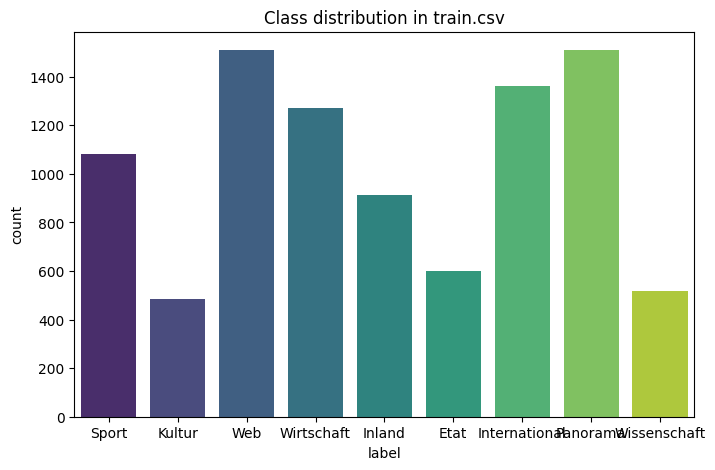

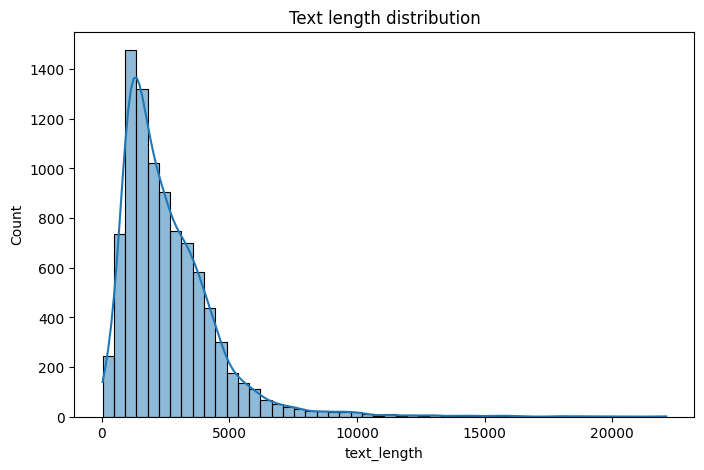

label          0
text           0
id             0
text_length    0
dtype: int64


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df.head()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

plt.figure(figsize=(8,5))
sns.countplot(x="label", data=train_df, palette="viridis")
plt.title("Class distribution in train.csv")
plt.show()

train_df["text_length"] = train_df["text"].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(train_df["text_length"], bins=50, kde=True)
plt.title("Text length distribution")
plt.show()

print(train_df.isnull().sum())


1.2. Pre-processing of data

In [11]:
import re
import nltk
from nltk.corpus import stopwords

# Завантаження стоп-слів для німецької
nltk.download("stopwords")
german_stopwords = set(stopwords.words("german"))

def preprocess_text(text):
    text = str(text).lower()                           # нижній регістр
    text = re.sub(r"[^a-zäöüß ]", " ", text)           # видалення символів
    tokens = text.split()
    tokens = [t for t in tokens if t not in german_stopwords]  # стоп-слова
    return " ".join(tokens)

# Створюємо колонку clean_text
train_df["clean_text"] = train_df["text"].apply(preprocess_text)
test_df["clean_text"] = test_df["text"].apply(preprocess_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Adminn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1.3. Data transformation and Generation

Size of matrix train: (9245, 5000)
Size of matrix test: (1028, 5000)


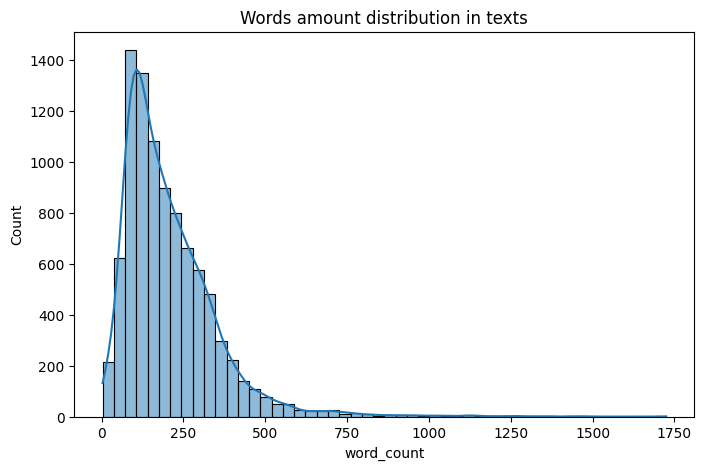

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

#TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(train_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

print("Size of matrix train:", X.shape)
print("Size of matrix test:", X_test.shape)

train_df["word_count"] = train_df["clean_text"].apply(lambda x: len(x.split()))
test_df["word_count"] = test_df["clean_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(train_df["word_count"], bins=50, kde=True)
plt.title("Words amount distribution in texts")
plt.show()

## 2. Training a machine learning model

2.1. Selection and comparison of architectures

In [14]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

train_df = pd.read_csv("train.csv")

X_train, X_val, y_train, y_val = train_test_split(
    train_df["text"], train_df["label"], test_size=0.2, random_state=42, stratify=train_df["label"]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="lbfgs"),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

for name, clf in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ("clf", clf)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    print(f"=== {name} ===")
    print(classification_report(y_val, y_pred))

=== Logistic Regression ===
               precision    recall  f1-score   support

         Etat       0.92      0.66      0.77       120
       Inland       0.76      0.77      0.76       183
International       0.82      0.82      0.82       272
       Kultur       0.79      0.76      0.77        97
     Panorama       0.71      0.79      0.75       302
        Sport       0.99      0.95      0.97       216
          Web       0.86      0.89      0.87       302
   Wirtschaft       0.72      0.78      0.75       254
 Wissenschaft       0.83      0.66      0.74       103

     accuracy                           0.81      1849
    macro avg       0.82      0.79      0.80      1849
 weighted avg       0.81      0.81      0.81      1849

=== Naive Bayes ===
               precision    recall  f1-score   support

         Etat       0.98      0.38      0.55       120
       Inland       0.71      0.72      0.72       183
International       0.76      0.79      0.78       272
       Kultur

2.2. Cross-Validation

In [15]:
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

scores = cross_val_score(pipeline, train_df["text"], train_df["label"], cv=5, scoring="accuracy")
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.81233099 0.81557599 0.81773932 0.78853434 0.81990265]
Mean accuracy: 0.8108166576527853


2.3. Hyperparameter selection

In [16]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

param_grid = {
    "tfidf__max_features": [3000, 5000, 10000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=2)
grid.fit(train_df["text"], train_df["label"])

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'clf__C': 10, 'clf__class_weight': None, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1)}
Best CV score: 0.8415354819259896


## 3. Review of results

3.1. Visualization of results

d:\Masters\9_semestr\Deep Learning\text_classification_task\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.4.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Masters\9_semestr\Deep Learning\text_classification_task\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.4.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Masters\9_semestr\Deep Learning\text_classification_task\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersio

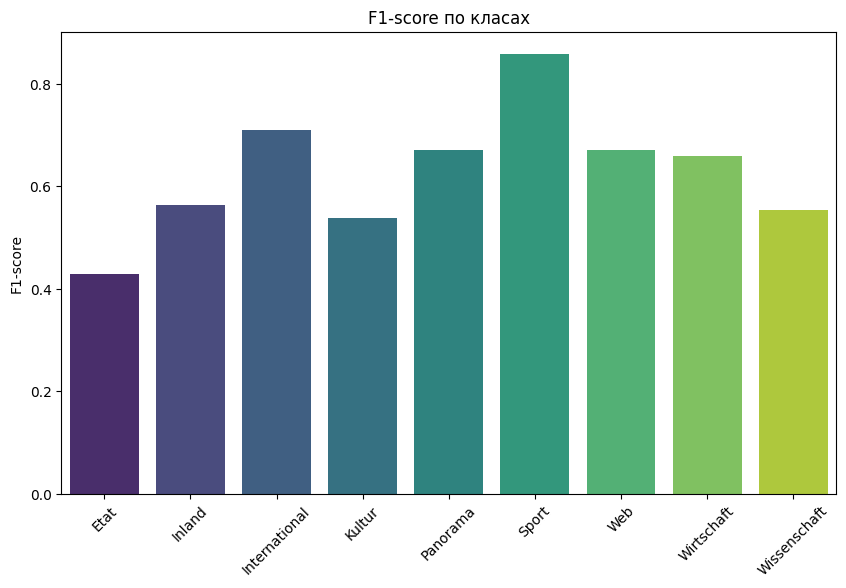

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import joblib

pipeline = joblib.load("model.pkl")   # завантажуємо готову модель 
y_pred = pipeline.predict(X_val)
report = classification_report(y_val, y_pred, output_dict=True)
scores = {label: metrics["f1-score"] for label, metrics in report.items() if label not in ["accuracy", "macro avg", "weighted avg"]}

plt.figure(figsize=(10,6))
sns.barplot(x=list(scores.keys()), y=list(scores.values()), palette="viridis")
plt.title("F1-score по класах")
plt.xticks(rotation=45)
plt.ylabel("F1-score")
plt.show()

3.2. classification report

In [20]:
from sklearn.metrics import classification_report

print("=== Classification Report ===")
print(classification_report(y_val, y_pred))

=== Classification Report ===
               precision    recall  f1-score   support

         Etat       0.97      0.28      0.43       120
       Inland       0.86      0.42      0.56       183
International       0.84      0.62      0.71       272
       Kultur       0.42      0.75      0.54        97
     Panorama       0.56      0.82      0.67       302
        Sport       0.99      0.75      0.86       216
          Web       0.96      0.52      0.67       302
   Wirtschaft       0.55      0.82      0.66       254
 Wissenschaft       0.42      0.83      0.55       103

     accuracy                           0.66      1849
    macro avg       0.73      0.65      0.63      1849
 weighted avg       0.76      0.66      0.66      1849



3.3. Confusion Matrix

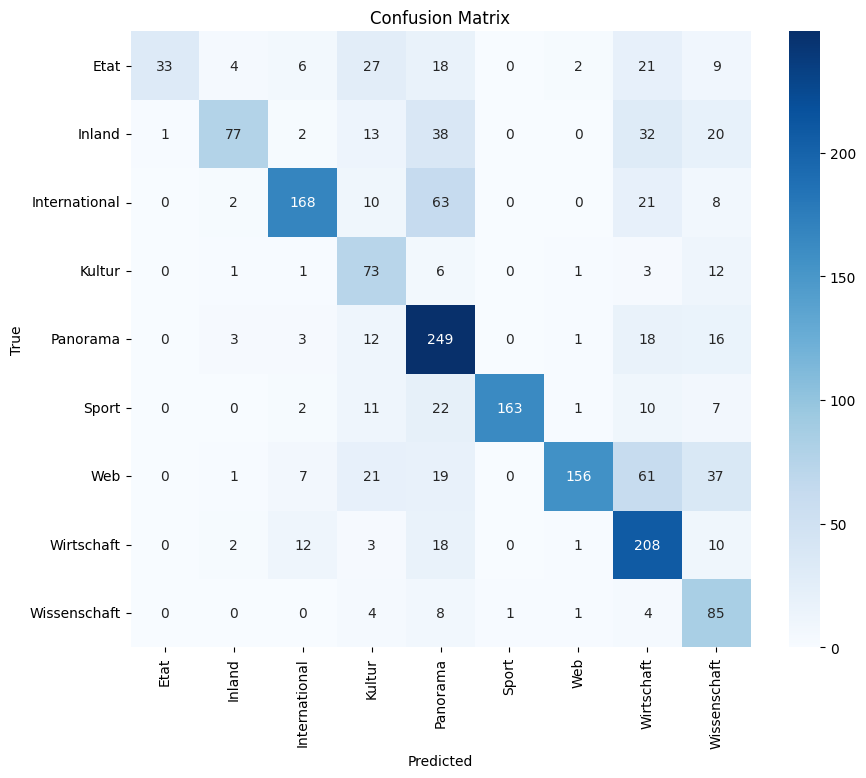

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred, labels=pipeline.classes_)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

3.4. Accuracy

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6554894537587885


4. Final Accuracy

Feature Engineering

In [24]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    sublinear_tf=True,
    min_df=5
)

Using LinearSVC (stronger than Logistic Regression)

In [25]:
from sklearn.svm import LinearSVC

pipeline = Pipeline([
    ("tfidf", tfidf),
    ("clf", LinearSVC(C=1.0))
])

Class balance

In [26]:
LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [27]:
LinearSVC(class_weight="balanced")

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

Cross-Validation & GridSearchCV

In [28]:
param_grid = {
    "tfidf__max_features": [10000, 20000, 50000],
    "tfidf__ngram_range": [(1,2), (1,3)],
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

In [29]:
joblib.dump(pipeline, "final_model.pkl")
print("Final model saved to final_model.pkl")

Final model saved to final_model.pkl


In [31]:
pipeline.fit(X_train, y_train)
joblib.dump(pipeline, "final_model.pkl")

['final_model.pkl']

In [32]:
from sklearn.metrics import accuracy_score

train_df = pd.read_csv("train.csv")

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    train_df["text"], train_df["label"], test_size=0.2, random_state=42, stratify=train_df["label"]
)

pipeline = joblib.load("final_model.pkl")

y_pred = pipeline.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print("Final Accuracy:", accuracy)

Final Accuracy: 0.8355868036776636
